In [159]:
import sys
sys.path.insert(0, "/home/winnieyangwn/rllm")
import importlib

import analysis.utils.eval_utils as eval_utils 

importlib.reload(eval_utils)
from analysis.utils.eval_utils import *

In [160]:
data_path = "/checkpoint/maui_sft/winnieyangwn/mlebench_dumps/multi_node_2_tasks/results/trajectories.jsonl"

In [161]:
import pandas as pd

df = pd.read_json(data_path, lines=True)


Found 128 rollouts matching valid criteria
Found 0 rollouts matching invalid criteria (excluding infra errors)
Found 0 rollouts with infrastructure errors


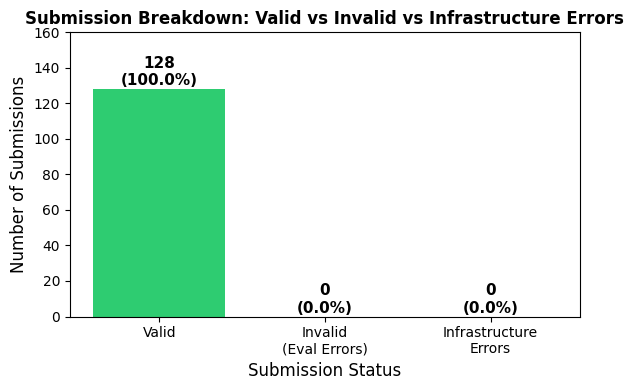

In [162]:
valid_df, invalid_df, infra_df = plot_submission_validity_breakdown(df)

In [163]:
# Test process_df function
importlib.reload(eval_utils)
from analysis.utils.eval_utils import process_df

df_processed, df_task = process_df(df, Ks=[1, 4, 8, 16, 24, 32, 40, 48, 56, 64])

print("=== df_processed (rollout-level) ===")
print(f"Shape: {df_processed.shape}")


print("\n\n=== df_task (task-level) ===")
print(f"Shape: {df_task.shape}")
display(df_task)

=== df_processed (rollout-level) ===
Shape: (128, 17)


=== df_task (task-level) ===
Shape: (2, 28)


,n_rollouts,pass@1,pass@4,pass@8,pass@16,pass@24,pass@32,pass@40,pass@48,pass@56,...,valid_pass@48,valid_pass@56,valid_pass@64,any_medal_rate,gold_medal_rate,silver_medal_rate,bronze_medal_rate,gold_threshold,silver_threshold,bronze_threshold
task_name,,,,,,,,,,,,,,,,,,,,,
mlsp-2013-birds,64,0.319252,0.421203,0.49152,0.579187,0.642063,0.689857,0.724836,0.748365,0.761574,...,1.0,1.0,1.0,0.031250,0.0,0.000000,0.03125,0.907407,0.808642,0.611111
spooky-author-identification,64,0.610784,0.723083,0.77325,0.828135,0.861117,0.885227,0.904809,0.921733,0.937083,...,1.0,1.0,1.0,0.015625,0.0,0.015625,0.00000,0.990741,0.950483,0.900161


In [164]:
get_summary_stats(df)

{'total': 128,
 'valid_submissions': 128,
 'valid_rate': np.float64(100.0),
 'passed': 128,
 'pass_rate': np.float64(100.0),
 'avg_percentile': np.float64(0.4650177804616206),
 'min_percentile': np.float64(0.0016103059581320002),
 'max_percentile': np.float64(0.9516908212560381),
 'avg_score': np.float64(0.7225616406250001)}

In [165]:
df.shape

(128, 9)

Using pre-computed pass@k for 2 tasks
Tasks: ['mlsp-2013-birds', 'spooky-author-identification']


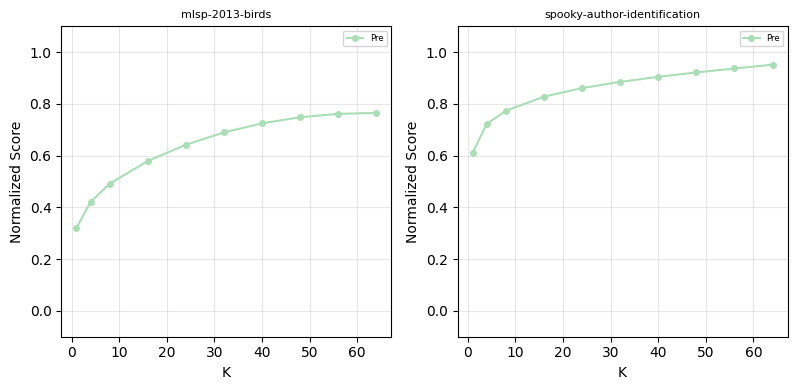

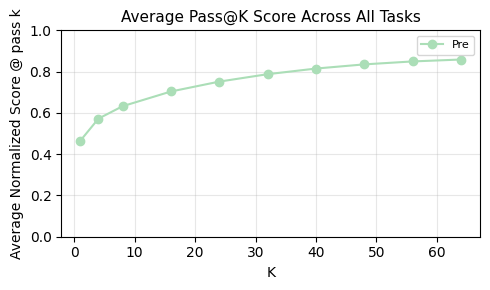

K	Pre
1	0.4650
4	0.5721
8	0.6324
16	0.7037
24	0.7516
32	0.7875
40	0.8148
48	0.8350
56	0.8493
64	0.8586


In [166]:
# Test pass@k for percentile scores
results_df = plot_pass_at_k(df_task, metric="percentile")

In [156]:
# Compare metrics across the full dataset
plot_metric_comparison([df_processed], labels=["All"], metric="percentile", agg="mean")


plot_metric_comparison([df_processed], labels=["All"], metric="medal", agg="mean")



Mean Percentile All: 0.4650 ± 0.1883


Mean Any Medal All: 0.0234 ± 0.1519
Mean Gold Medal All: 0.0000 ± 0.0000
Mean Silver Medal All: 0.0078 ± 0.0884
Mean Bronze Medal All: 0.0156 ± 0.1245


({'any_medal': {'values': [np.float64(0.0234375)],
   'stds': [np.float64(0.1518828677363284)]},
  'gold_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'silver_medal': {'values': [np.float64(0.0078125)],
   'stds': [np.float64(0.08838834764831845)]},
  'bronze_medal': {'values': [np.float64(0.015625)],
   'stds': [np.float64(0.12450690143095285)]}},
 None)